C:\Users\Jamal2000\anaconda3\lib\site-packages\sklearn\base.py:413: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

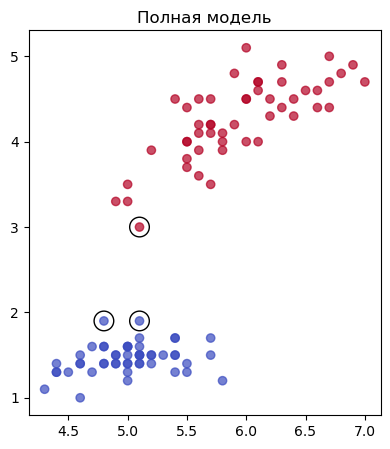

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.svm import SVC

# Загрузка датасета
iris = sns.load_dataset("iris")
data = iris[["sepal_length", "petal_length", "species"]]
data_df = data[(data["species"] == "setosa") | (data["species"] == "versicolor")]

X_full = data_df[["sepal_length", "petal_length"]]
y_full = data_df["species"]

# Обучение полной модели
model_full = SVC(kernel='linear', C=10000)
model_full.fit(X_full, y_full)

# Сохраняем опорные векторы
support_vectors = model_full.support_vectors_

# Теперь удалим ВСЕ НЕопорные векторы и обучим модель заново
X_reduced = support_vectors
# Получаем метки классов, соответствующие опорным векторам
y_reduced = y_full.iloc[model_full.support_]

model_reduced = SVC(kernel='linear', C=10000)
model_reduced.fit(X_reduced, y_reduced)

# Построим график сравнения
plt.figure(figsize=(10, 5))

# Сетка точек для отображения границ
x1_p = np.linspace(min(X_full["sepal_length"]), max(X_full["sepal_length"]), 100)
x2_p = np.linspace(min(X_full["petal_length"]), max(X_full["petal_length"]), 100)
X1_p, X2_p = np.meshgrid(x1_p, x2_p)

X_p = pd.DataFrame(np.vstack([X1_p.ravel(), X2_p.ravel()]).T,
                   columns=["sepal_length", "petal_length"])

# Предсказания обеих моделей
y_pred_full = model_full.predict(X_p)
y_pred_reduced = model_reduced.predict(X_p)

# Визуализация
plt.subplot(1, 2, 1)
plt.title("Полная модель")
plt.scatter(X_full["sepal_length"], X_full["petal_length"], c=y_full.map({"setosa": 0, "versicolor": 1}), cmap='coolwarm', alpha=0.7)
plt.scatter(model_full.support_vectors_[:, 0], model_full.support_vectors_[:, 1], s=200, facecolor='none', edgecolor='black')
plt.contourf(X1_p, X2_p, y_pred_full.reshape(100, 100), alpha=0.2, cmap='coolwarm')

plt.subplot(1, 2, 2)
plt.title("Только опорные векторы")
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y_reduced.map({"setosa": 0, "versicolor": 1}), cmap='coolwarm', alpha=0.7)
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], s=200, facecolor='none', edgecolor='black')
plt.contourf(X1_p, X2_p, y_pred_reduced.reshape(100, 100), alpha=0.2, cmap='coolwarm')

plt.tight_layout()
plt.show()
